***Homework 2: The goal of this homework is to create a regression model for predicting the car fuel efficiency (column 'fuel_efficiency_mpg')***

In [35]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn
#import wget

np.set_printoptions(legacy='1.25')

The goal of this homework is to create a regression model for predicting the car fuel efficiency (column `'fuel_efficiency_mpg'`).

In [36]:
df = pd.read_csv("https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv")

In [37]:
# Let us have a quick look at the our dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   model_year           10000 non-null  int64  
 1   origin               10000 non-null  str    
 2   fuel_type            10000 non-null  str    
 3   drivetrain           10000 non-null  str    
 4   num_doors            10000 non-null  int64  
 5   engine_displacement  10000 non-null  int64  
 6   num_cylinders        10000 non-null  int64  
 7   horsepower           9123 non-null   float64
 8   vehicle_weight       10000 non-null  int64  
 9   acceleration         9736 non-null   float64
 10  fuel_efficiency_mpg  10000 non-null  float64
dtypes: float64(3), int64(5), str(3)
memory usage: 1.1 MB


### Prepare dataset


Use only the following columns:

* 'engine_displacement',

* 'horsepower',

* 'vehicle_weight',

* 'model_year',

* 'fuel_efficiency_mpg'

In [38]:
#Create a list with all the features we are going to keep to train our model

base = ['engine_displacement','horsepower','vehicle_weight','model_year','fuel_efficiency_mpg'] 

df = df[base]

### EDA


* Look at the `fuel_efficiency_mpg` variable. Does it have a long tail? 

In [39]:
df.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

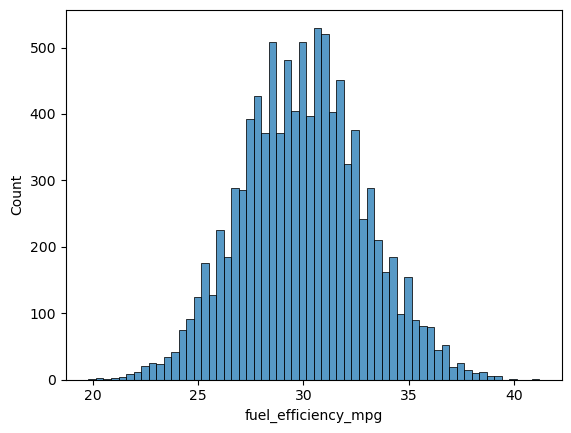

In [40]:
sns.histplot(df['fuel_efficiency_mpg'])

***Answer***: No, 'fuel_efficiency_mpg' does not have a lot tail. The variable seems to have a normal distribution

#### **Question 1**

There's one column with missing values. What is it?

'engine_displacement'

'horsepower'

'vehicle_weight'

'model_year'


In [41]:
df.isnull().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

*Answer:* **'horsepower'**

#### **Question 2**


What's the median (50% percentile) for variable `'horsepower'`?

- 204
- 254
- 304
- 354

In [42]:
df['horsepower'].median()

254.0

***Answer:*** 254

### Prepare and split the dataset

Shuffle the filtered dataset and create the split exactly as in the lecture:

In [43]:
#KEEP #Set a random seed and shuffle the observations in our dataset
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

In [44]:
#OK
len(df_train), len(df_val), len(df_test)

(6000, 2000, 2000)

For Q5, repeat the same block with each listed seed. For Q6, use seed `9`.

#### **Question 3**

* We need to deal with missing values for the column from Q1.

* We have two options: fill it with 0 or with the mean of this variable.

* Try both options. For each, train a linear regression model without regularization using the code from the lessons.

* For computing the mean, use the training only!

* Use the validation dataset to evaluate the models and compare the RMSE of each option.

* Round the RMSE scores to 2 decimal digits using round(score, 2)

* Which option gives better RMSE?

In [45]:
#Reset the index
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [46]:
#Create the target variable dataset
y_train = df_train["fuel_efficiency_mpg"]
y_val = df_val["fuel_efficiency_mpg"]
y_test = df_test["fuel_efficiency_mpg"]
del df_train["fuel_efficiency_mpg"]
del df_val["fuel_efficiency_mpg"]
del df_test["fuel_efficiency_mpg"]

In [47]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

**Option 1: filling missing values with 0 using the fillna options**

In [48]:
base = ['engine_displacement', 'horsepower', 'vehicle_weight']
base

['engine_displacement', 'horsepower', 'vehicle_weight']

In [49]:
#Let us find what is the most recent model year
df["model_year"].max()

2024

**Prepare data following the course code**

In [50]:
# Create the function to prepare our feature dataset
def prepare_X(df):
    df = df.copy()
    features = base.copy()

    df['age'] = 2024 - df['model_year']
    features.append('age')

    df_num = df[features]
    df_num = df_num.fillna(0) # Here we will input the missing data with 0

    X = df_num.values
    return X

In [51]:
# Create the linear regression function in order to retrieve the biais and the weights for the respective features
def train_linear_regression(X, y):
    # X a une dimension de 7150 par 5
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)
    
    return w[0], w[1:]

In [52]:
# Create the function to analyze our model prediction errors, RMSE
def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    rmse = np.sqrt(mse)
    return print("score:", round(rmse, 2))

In [53]:
#Prepare the data, get the linear regression weights, make prediction on the validation and finally get the predictior error score RMSE
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

rmse(y_val, y_pred)

score: 2.21


**Option 2: filling missing values with the mean values of the horsepower variable using the fillna options**

In [54]:
#Calculate the mean value of the variable 'horsepower' so that we can input the missing values in that column with the mean
#We will use the mean value of horsepower from the training dataset only
#HP_mean = round(df_train['horsepower'].mean(),2)
HP_mean = df_train['horsepower'].mean()
HP_mean

254.46338337605272

In [55]:
#Create the function to prepare our feature dataset for our linear regression model and replace the missing values 
#in the variable "horsepower" with the mean value of that variable in the training dataset

def prepare_X_mean(df):
    df = df.copy()
    features = base.copy()

    df['age'] = 2017 - df['model_year']
    features.append('age')

    df_num = df[features]
    df_num = df_num.fillna(HP_mean) # No need to specify dfdf_num['horsepower'] here as it is the only variable with missing values
    X = df_num.values
    return X

In [56]:
# preparare our training dataset for our linear regression model and get the model weights, run a prediction on the validation set and
# finally get the model prediction error score, RMSE
X_train_mean = prepare_X_mean(df_train) # Mettre à jour avec le bon df ! Attention on utilise quelle variable pour y-train
w0, w = train_linear_regression(X_train_mean, y_train)

X_val = prepare_X_mean(df_val)
y_pred = w0 + X_val.dot(w)

rmse(y_val, y_pred)

score: 2.2


***Answer:*** with the mean value

### **Question 4**

* Now let's train a regularized linear regression.
* For this question, fill the NAs with 0. 
* Try different values of `r` from this list: `[0, 0.01, 0.1, 1, 5, 10, 100]`.
* Use RMSE to evaluate the model on the validation dataset.
* Round the RMSE scores to 4 decimal digits. This keeps the small but real
  regularization differences visible instead of turning several choices into a tie.
* Which `r` gives the best RMSE?

If multiple options give the same best RMSE, select the smallest `r`.

Options:

- 0
- 0.01
- 0.1
- 1
- 5
- 10
- 100

In [57]:
#Create a new linear regression function which will take in an additionAL parameter "r`" for regularization
def train_linear_regression_reg(X, y, r):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    
    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])
    
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    return w_full[0], w_full[1:]

In [58]:
#Create a list "r" including all the values that we want the parameter are to take
r = [0, 0.01, 0.1, 1, 5, 10, 100]

Let us first run our regularized linear regression with a value of r = 0.01 first. We will loop the function with the different values for "r" later

In [59]:
w0, w = train_linear_regression_reg(X_train, y_train, r = 0.01)

X_val = prepare_X_mean(df_val)
y_pred = w0 + X_val.dot(w)

rmse(y_val, y_pred)

score: 2.3


In [60]:
#Redefining rmse function in order to answer to Question 4
def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    rmse = np.sqrt(mse)
    return print("score:", round(rmse, 4))

In [61]:
#Get the RMSE score, and weight value based on different regularization value
for r in [0.0, 0.00001, 0.0001, 0.001, 0.1, 1, 10]:
    X_train = prepare_X(df_train)
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)

    X_val = prepare_X(df_val)
    y_pred = w0 + X_val.dot(w)

    score = rmse(y_val, y_pred)
    print("R value: {} , w0 value: {}".format(r,w0))
    print()

score: 2.2053
R value: 0.0 , w0 value: 52.86013086867689

score: 2.2053
R value: 1e-05 , w0 value: 52.86010735948321

score: 2.2053
R value: 0.0001 , w0 value: 52.85989577773569

score: 2.2053
R value: 0.001 , w0 value: 52.85778005336053

score: 2.205
R value: 0.1 , w0 value: 52.626079808253266

score: 2.2064
R value: 1 , w0 value: 50.60931453089121

score: 2.4023
R value: 10 , w0 value: 36.58789751162733



***Answer:*** the best "r" parameter is 0

### **Question 5**

* We used seed 42 for splitting the data. Let's find out how selecting the seed influences our score.
* Try different seed values: `[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]`.
* For each seed, do the train/validation/test split with 60%/20%/20% distribution.
* Fill the missing values with 0 and train a model without regularization.
* For each seed, evaluate the model on the validation dataset and collect the RMSE scores. 
* What's the standard deviation of all the scores? To compute the standard deviation, use `np.std`.
* Round the result to 3 decimal digits (`round(std, 3)`)

What's the value of std?

- 0.006
- 0.016
- 0.029
- 0.036

> Note: Standard deviation shows how different the values are.
> If it's low, then all values are approximately the same.
> If it's high, the values are different. 
> If standard deviation of scores is low, then our model is *stable*.

In [62]:
seed_list = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

In [63]:
def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    rmse = np.sqrt(mse)
    return round(rmse, 3)

In [64]:
rmse_list = []
    
for i in seed_list: 
    np.random.seed(i)
    
    n = len(df)
    idx = np.arange(n)
    np.random.shuffle(idx)
    
    df_shuffled = df.iloc[idx]
    
    print("Seed value: {}".format(i))
        
    df_train2 = df_shuffled.iloc[:n_train].copy()
    df_val2 = df_shuffled.iloc[n_train:n_train+n_val].copy()
    df_test2 = df_shuffled.iloc[n_train+n_val:].copy()
    
    # Target variable
    y_train2 = df_train2['fuel_efficiency_mpg']
    y_val2 = df_val2['fuel_efficiency_mpg']
    y_test2 = df_test2['fuel_efficiency_mpg']
    
    del df_train2['fuel_efficiency_mpg']
    del df_val2['fuel_efficiency_mpg']
    del df_test2['fuel_efficiency_mpg']
    
    # Train model
    X_train2 = prepare_X(df_train2)
    w0, w = train_linear_regression(X_train2, y_train2)

    # Validate
    X_val2 = prepare_X(df_val2)
    y_pred = w0 + X_val2.dot(w)

    score = rmse(y_val2, y_pred)
    print("score:", score)
    rmse_list.append(score)
    print()

Seed value: 0
score: 2.239

Seed value: 1
score: 2.202

Seed value: 2
score: 2.163

Seed value: 3
score: 2.204

Seed value: 4
score: 2.202

Seed value: 5
score: 2.246

Seed value: 6
score: 2.27

Seed value: 7
score: 2.191

Seed value: 8
score: 2.217

Seed value: 9
score: 2.207



In [65]:
# Display a list with all the scores you obtained by setting a different seed number
rmse_list

[2.239, 2.202, 2.163, 2.204, 2.202, 2.246, 2.27, 2.191, 2.217, 2.207]

In [66]:
# Calculate the score standard deviation
std = np.std(rmse_list)
std

0.028915220905260306

In [67]:
std = round(std, 3)
std

0.029

***Answer:*** 0.029

#### **Question 6**

* Split the dataset like previously, use seed 9.
* Combine train and validation datasets.
* Fill the missing values with 0 and train a model with `r=0.001`. 
* What's the RMSE on the test dataset?

Options:

- 0.236
- 2.236
- 22.10
- 221.0

In [94]:
np.random.seed(9)

n = len(df)

idx = np.arange(n)
np.random.shuffle(idx)

df_shuffled = df.iloc[idx]

df_shuffled

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
3644,2320,246.0,4100,2014,32.5
9184,2230,252.0,4250,1998,33.2
520,2700,276.0,4490,2008,32.4
5685,2220,269.0,4060,2004,29.9
2401,2370,NaN,4690,1979,26.4
...,...,...,...,...,...
6200,2260,250.0,4170,1996,33.3
501,2300,249.0,4360,2015,29.9
6782,2240,265.0,4170,1982,31.0
4444,2380,278.0,4210,1978,27.2


In [95]:
# Split the dataset into train and validation dataset etc...
df_train = df_shuffled.iloc[:n_train].copy()
df_val = df_shuffled.iloc[n_train:n_train+n_val].copy()
df_test = df_shuffled.iloc[n_train+n_val:].copy()

df_train.shape, df_val.shape, df_test.shape # ME : DO I NEED TO RESET THE INDEX

((6000, 5), (2000, 5), (2000, 5))

In [96]:
df_train

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
3644,2320,246.0,4100,2014,32.5
9184,2230,252.0,4250,1998,33.2
520,2700,276.0,4490,2008,32.4
5685,2220,269.0,4060,2004,29.9
2401,2370,NaN,4690,1979,26.4
...,...,...,...,...,...
7911,1950,231.0,4150,1989,32.8
251,2060,249.0,3910,2012,31.3
2298,2180,223.0,4360,2014,34.1
1741,2420,248.0,4080,1977,27.1


In [97]:
#Create our variable target dataset
y_train = df_train['fuel_efficiency_mpg']
y_val = df_val['fuel_efficiency_mpg']
y_test = df_test['fuel_efficiency_mpg']

y_train.shape,y_val.shape, y_test.shape

((6000,), (2000,), (2000,))

In [98]:
# Drop the target variable from the dataset
del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

In [99]:
# Concatenate the training and validation dataset, and the training + validation targe
df_train_full = pd.concat([df_train,df_val]).reset_index(drop=True)

In [100]:
df_train_full

,engine_displacement,horsepower,vehicle_weight,model_year
0,2320,246.0,4100,2014
1,2230,252.0,4250,1998
2,2700,276.0,4490,2008
3,2220,269.0,4060,2004
4,2370,NaN,4690,1979
...,...,...,...,...
7995,2690,324.0,4510,2023
7996,1920,190.0,4000,1998
7997,1800,225.0,3980,1994
7998,1970,232.0,3560,2009


In [101]:
df_train_full.shape

(8000, 4)

In [102]:
# Concatenate the training + validation targets
y_train_full = pd.concat([y_train,y_val]).reset_index(drop=True)
y_train_full

0       32.5
1       33.2
2       32.4
3       29.9
4       26.4
        ... 
7995    35.7
7996    30.8
7997    29.1
7998    32.2
7999    35.6
Name: fuel_efficiency_mpg, Length: 8000, dtype: float64

In [103]:
y_train_full.shape

(8000,)

In [104]:
type(y_train_full)

pandas.Series

In [105]:
X_train_full = prepare_X(df_train_full)
X_train_full

array([[2320.,  246., 4100.,   10.],
       [2230.,  252., 4250.,   26.],
       [2700.,  276., 4490.,   16.],
       ...,
       [1800.,  225., 3980.,   30.],
       [1970.,  232., 3560.,   15.],
       [2180.,  254., 3970.,    6.]])

In [106]:
w0, w = train_linear_regression_reg(X_train_full, y_train_full, r = 0.001) # je dois faire un df prepare avec la

X_test = prepare_X(df_test)
y_pred = w0 + X_test.dot(w)

rmse(y_test, y_pred)

2.236

***Answer:*** 2.236